<a href="https://colab.research.google.com/github/Muskanpoddar/Animated-Website/blob/main/SVM/Spam_email_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Spam Classification Accuracy: 0.8533333333333334
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        75
           1       0.85      0.85      0.85        75

    accuracy                           0.85       150
   macro avg       0.85      0.85      0.85       150
weighted avg       0.85      0.85      0.85       150



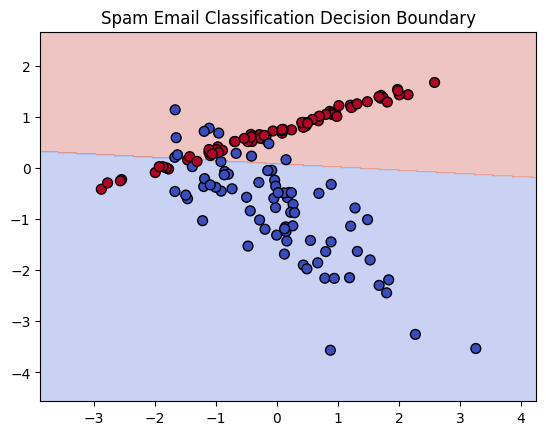

In [14]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Generate synthetic spam data
X_spam, y_spam = make_classification(n_samples=500, n_features=2, n_informative=2,
                                     n_redundant=0, n_clusters_per_class=1, random_state=42)

# Split data
X_train_spam, X_test_spam, y_train_spam, y_test_spam = train_test_split(X_spam, y_spam, test_size=0.3, random_state=42)

# Scale features
sc_spam = StandardScaler()
X_train_spam = sc_spam.fit_transform(X_train_spam)
X_test_spam = sc_spam.transform(X_test_spam)

# Train linear SVM
model_spam = SVC(kernel='linear', random_state=0)
model_spam.fit(X_train_spam, y_train_spam)

# Predict
y_pred_spam = model_spam.predict(X_test_spam)

print("Spam Classification Accuracy:", accuracy_score(y_test_spam, y_pred_spam))
print(classification_report(y_test_spam, y_pred_spam))

# Plot decision boundary with exact styles
def plot_decision_boundary(model, X, y):
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='coolwarm', s=50)
    plt.title("Spam Email Classification Decision Boundary")
    plt.show()

plot_decision_boundary(model_spam, X_test_spam, y_test_spam)
